# Day 015 · 时间序列与平稳性
**Stationarity** · 阶段 P1 · 量化基础

> 时间序列与平稳性是金融数据分析的两个根本起点。今天讲清楚四件事:① 平稳性是什么 — 一个序列的均值、方差、协方差不随时间漂移;② ADF 检验怎么算 + 怎么解读 — 一行代码给你 p 值,p 小于零点零五就是平稳;③ 价格几乎都不平稳 / 收益率几乎都平稳 — 这是为什么所有量化分析必须先做对数收益;④ 协整 — 两个非平稳序列的某种线性组合是平稳的,这是配对交易的理论根基。**学完这节你能用三行代码判断任何时间序列能不能直接做回归,以及任何两个标的能不能配对**。今天我们用沪深三百价格 vs 收益率做完美对照,然后用中信证券 + 华泰证券两家券商龙头测协整 — 实测结果反直觉,等会你看。

---

**课件生成日期:** 2026-05-05  ·  **建议学习时长:** 20 分钟

学习路径建议:1)先看视频建立直觉 → 2)阅读本 notebook 跑代码 → 3)看 PDF 课件复习要点 → 4)做自测题

## 🔧 第一步:环境自检 + 自动安装

**第一次拿到这份 notebook,请先运行下面这一格。** 它会:
1. 检查所有需要的 Python 包,缺什么自动 `pip install` 装上
2. 注入中文字体到 matplotlib(让图标不出乱码)
3. 跑完看到 `✓ 环境就绪` 就可以继续下面的代码

> 这一格只在第一次跑要等几十秒,后面再开 notebook 就秒过。

In [1]:
# === 环境自检 + 自动安装(运行此单元格即可) ===
# 检测缺失的库 → 自动 pip 安装 → 注入中文字体 → 一行命令搞定
import importlib
import subprocess
import sys
import os

REQUIRED = ["matplotlib", "numpy", "numpy_financial", "pandas", "scipy", "sklearn", "statsmodels", "yfinance"]
PIP_NAME = {
    "sklearn": "scikit-learn",
    "cv2": "opencv-python",
    "PIL": "Pillow",
    "bs4": "beautifulsoup4",
    "yaml": "PyYAML",
}

missing = []
for mod in REQUIRED:
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(PIP_NAME.get(mod, mod))

if missing:
    print(f"⏳ 缺少 {len(missing)} 个包,正在自动安装:{missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("✓ 安装完成")
else:
    print(f"✓ 所有 {len(REQUIRED)} 个必需库已就绪")

# === 中文字体配置(让 matplotlib 不出乱码) ===
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

CJK_FONT_PATHS = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",  # Linux/WSL
    "C:/Windows/Fonts/msyh.ttc",                               # Windows 微软雅黑
    "C:/Windows/Fonts/simhei.ttf",                             # Windows 黑体
    "/System/Library/Fonts/PingFang.ttc",                      # macOS 苹方
    "/System/Library/Fonts/STHeiti Medium.ttc",                # macOS 黑体
]
for p in CJK_FONT_PATHS:
    if os.path.exists(p):
        fm.fontManager.addfont(p)
        print(f"✓ 中文字体已加载:{os.path.basename(p)}")
        break
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP", "Microsoft YaHei",
                                    "PingFang SC", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
print("✓ 环境就绪 — 现在可以跑下面的代码单元格")


✓ 所有 8 个必需库已就绪
✓ 中文字体已加载:NotoSansCJK-Regular.ttc
✓ 环境就绪 — 现在可以跑下面的代码单元格


## 学习目标

- 理解时间序列的定义 — 按时间顺序的数据,以及为什么金融数据必须按时间序列而不是独立观察分析
- 掌握平稳性的三个要求 — 均值不变、方差不变、协方差只跟时间差有关
- 会用 ADF 检验判断任何序列是否平稳 — 一行 statsmodels 代码 + p 值解读
- 知道为什么金融价格几乎都不平稳但日收益率都平稳 — 量化分析必先做对数收益的根本原因
- 理解协整的本质 — 两个非平稳序列的线性组合可能是平稳的,这是配对交易理论根基
- 会用 Engle-Granger 协整检验判断任何两个标的能不能做配对交易,并用实测数据看反直觉案例

## 历史背景:Tartaglia 摩根斯坦利 1980s 配对交易起源 + 中信华泰 2024 协整失效反直觉

配对交易的故事要从一九八零年代讲起。当时摩根斯坦利有一个叫 Nunzio Tartaglia 的物理学家组建了一个量化团队,他们发现两只同行业股票的价差(spread)看起来有'回到均值'的特性 — 涨开了会回落,跌开了会反弹。他们用统计方法挖掘这种关系,把当时几千只美股做两两配对,发现可乐与百事、麦当劳与汉堡王、福特与通用汽车这种'双胞胎'对子有显著协整关系。摩根斯坦利就用这个套利,一九八五到一九八九年策略团队从十几个人扩到二三十个人,赚了很多钱。这是配对交易最早的故事。

后来 Renaissance Technologies 的 Simons 团队在一九八零年代末也独立开发了类似策略,他们处理得比摩根斯坦利更系统化,用 ADF 和协整检验做严格的统计验证,只交易统计上确实平稳的 spread。这种纪律让他们一九八八年开始连续三十年保持赢利。

但配对交易也有反面故事。**LTCM 长期资本管理公司一九九八年那次倒闭**,核心策略之一就是配对交易 — 美国国债和外国国债之间、不同期限之间的协整。问题是他们的协整检验只用了过去四到五年数据,全是平静期。一九九八年俄罗斯违约,一切协整关系瞬间崩溃,他们几个月亏了百分之九十的资本。教训是:**协整不是永恒的关系,会随宏观环境变化**。

**中国市场二零二四到二零二五年也有一个反直觉的实测**。我们今天的代码用中信证券和华泰证券做配对 — 这两家是中国券商行业的两个头部巨头,按'同行业龙头应该协整'的教科书逻辑,关系应该非常紧密。但实测结果给出 Engle-Granger 协整 p 值零点二八五二,远高于零点零五的显著性门槛 — **协整不成立**。原因是二零二四年国九条新规 + 严监管 + 行业内分化加剧,头部券商之间的走势开始脱钩,有的吃到投行政策红利,有的被资管业务下滑拖累。

这告诉散户最深刻的一课:**配对交易不能靠直觉,必须用 ADF + 协整检验实测验证,否则可能错配仓位** — 教科书'应该协整'的对子,在实战可能根本不协整。每季度还要复检,因为关系会变。

**关键人物:**
- Nunzio Tartaglia(一九八零年代摩根斯坦利量化团队负责人,配对交易始祖)
- James Simons / Renaissance(独立开发协整 + 平稳性纪律,三十年无年度亏损)
- Engle 与 Granger(一九八七年协整理论奠基,二零零三年诺贝尔经济学奖)
- Dickey 与 Fuller(一九七九年 ADF 检验提出者)
- LTCM 长期资本管理公司(一九九八年协整假设崩溃反面教训)

## 核心概念

下面每一节是听完视频后回头细读的内容。

### 1. 时间序列与平稳性的三个要求

时间序列的定义:**按时间顺序记录的数据**,不能打乱。股价每天的收盘价、每月的 GDP、每秒的订单流,都是时间序列。
跟横截面数据(比如 Day 14 我们做的多只股票一天的回归)的区别:横截面是'同一时刻不同个体',时间序列是'同一个体不同时刻'。
**为什么不能打乱?**因为时间序列本身就有'今天和昨天有关'的内部结构,打乱了这个结构就丢失了所有信息。
**平稳性 stationarity** 是时间序列分析最基础的概念。一个序列被认为是'平稳的',必须满足三个要求:
- 均值不变 — 整个序列的平均值不随时间漂移
- 方差不变 — 整个序列的波动幅度不随时间漂移
- 协方差只跟时间差有关 — 今天和昨天、明天和后天的关系结构稳定
直觉:**平稳序列就像一个固定温度下的水池**,水位上下波动但围着一个均值;非平稳序列像一个被人加水或排水的水池,均值随时间漂移。
**为什么这件事重要?**因为几乎所有时间序列工具(回归、ARIMA、协整)都假设输入是平稳的。如果你拿不平稳的数据直接做回归,得到的 t 统计量、p 值、R² 都是假的(术语叫'伪回归')。

```
平稳性三条件:E[X_t] = μ(常数)· Var[X_t] = σ²(常数)· Cov(X_t, X_{t-k}) 只跟 k 有关
```

> **举例:** 实测对照:沪深三百价格 — 二零二二年四千五百点 / 二零二四年三千点 / 二零二五年又回四千五百点,均值随时间漂移 → 非平稳(ADF p=0.5953)。沪深三百日收益率 — 围绕零均值上下波动,方差近似稳定 → 平稳(ADF p=0.0000)。同一个底层资产,价格非平稳但收益平稳,这是教科书最完美的对照。


### 2. ADF 检验 — 单位根判官 / 一行代码 + 一个 p 值

ADF 全名 Augmented Dickey-Fuller test,中文叫'扩展迪基-富勒检验',是一九七九年 Dickey 和 Fuller 提出的判定时间序列是否平稳的标准方法。
**核心思想**:检验序列是否存在'单位根'。单位根是数学上不平稳序列的核心特征。
**零假设和备择假设**:
- H₀(零假设):序列有单位根 → 不平稳
- H₁(备择假设):序列没有单位根 → 平稳
ADF 检验出来的 p 值就是'假设序列不平稳的概率'。所以解读完全反过来:
- p < 0.05 → 拒绝 H₀ → **序列平稳**
- p > 0.05 → 不能拒绝 H₀ → **不平稳(更准确说:数据不足以证明它平稳)**
**Python 一行**:`from statsmodels.tsa.stattools import adfuller; stat, p, *_ = adfuller(series)`
**实测对照**(我们今天代码跑出来的):
- 沪深三百价格 ADF p = 0.5953 → 远超 0.05 → **非平稳**
- 沪深三百日收益率 ADF p = 0.0000 → 远小于 0.05 → **平稳**
这就是教科书最完美的对照例子:同一个底层资产,价格本身是不平稳的(均值随时间漂移),但其收益率是平稳的(围绕零均值)。

```
ADF: H₀: 有单位根(不平稳) · H₁: 平稳 · 决策:p < 0.05 → 拒绝 H₀ → 平稳
```

> **举例:** 实测沪深三百价格 ADF p=0.5953 → 不平稳。把价格做一阶差分(p_t - p_{t-1})就得到日收益率,ADF p=0.0000 → 平稳。**这是为什么所有量化分析必先做对数收益**:从不平稳变成平稳,所有统计工具才能用。实战:任何新数据集,第一件事就是 ADF 检验,不平稳就差分,直到平稳为止。


### 3. 差分这个魔法 — 把非平稳变平稳

金融时间序列有一个普遍规律:**几乎所有资产价格都不平稳,但其日收益率几乎都平稳**。
**为什么价格不平稳**:
- 均值漂移:股价跟随基本面变化、估值变化、市场风险偏好,长期会有方向性
- 方差不稳定:不同时期的波动幅度差异大(平静期 vs 危机期)
- 没有'回归均值'的天然机制 — 一只股票从十元涨到一百元,没有数学理由要回到十元
**为什么收益率平稳**:
- 收益率 = (今天 - 昨天) / 昨天 ≈ 对数(今天) - 对数(昨天) — 这是个差分
- 差分把'水平漂移'消除了,留下的就是'变化幅度',围绕零波动
- 即使危机期波动大,长期均值仍接近零(年化 5%-10% 是均值,日均接近零)
**实战意义**:任何要做回归、ARIMA、协整、机器学习预测的金融时间序列,**第一步永远是把价格转成对数收益**。直接用价格会出现'伪回归' — 因为两个非平稳序列哪怕完全独立,普通回归也能跑出 R² 高、t 统计量大、p 值小的'显著结果',全是假的。
**Granger 一九七四年经典论文**就讲这件事 — 两个独立随机游走的序列做线性回归,有 75% 概率得到 p < 0.05 的'显著'结果。这是为什么 LTCM 这种顶尖团队也能踩坑 — 它们用了协整这种正确工具,但样本期太短没看到极端行情下的关系崩溃。

```
差分:Δy_t = y_t - y_{t-1}    对数收益:r_t = ln(p_t) - ln(p_{t-1})    多数金融价格一阶差分后平稳
```

> **举例:** 实测沪深三百:价格 ADF p=0.5953 不平稳;一阶差分得日收益,ADF p=0.0000 平稳 — 教科书完美对照。实战:看到任何研究材料用'股价'直接做回归 → 默认有问题。让对方解释为什么不做对数收益,几乎都是因为没经过专业训练,出来的统计结果是伪回归。


### 4. 协整 cointegration — 配对交易的理论根基

- **直觉故事**:两条狗各自都在城市里随机游走(不平稳),但如果它们被一根橡皮筋绑在一起,它们之间的'距离'就是平稳的 — 哪怕两条狗都漂移了很远,距离仍围绕橡皮筋长度波动。这就是协整。
- **数学定义**:两个非平稳序列 y 和 x,如果存在一个常数 β,使得 y - βx 是平稳的,那么这两个序列协整,β 叫'协整向量'或'hedge ratio'(对冲比例)。
- **金融意义**:虽然两只股票的股价都不平稳(各自漂移),但如果它们的'加权差'是平稳的,你就可以做**配对交易** — spread 大了做空贵的买便宜的,等回归均值赚价差。
- **Engle-Granger 协整检验**:(一九八七年提出,二零零三年诺贝尔经济学奖):

- 第一步:OLS 回归 y = α + β × x + ε,得到残差 ε(就是 spread)
- 第二步:对残差 ε 做 ADF 检验
- 第三步:如果 ε 的 ADF p < 0.05 → 协整成立 → 可做配对
- Python 一行:`from statsmodels.tsa.stattools import coint; t, p, _ = coint(y, x)`

- **实战配对交易流程**

1. 找候选对子(同行业 / 同主题 / 历史关联)
2. 各自 ADF 检验(都应该不平稳)
3. coint 协整检验(p < 0.05 才进下一步)
4. 算 hedge ratio 和 spread
5. 设入场出场阈值(±2σ 经典)
6. 每季度复检协整关系是否还成立

```
协整:∃β 使 y - βx 平稳(虽然 y、x 各自不平稳)· Engle-Granger:对残差 ε 做 ADF · p<0.05 协整成立
```

> **举例:** 可口可乐 vs 百事可乐协整 p<0.001 是教科书经典对子。但**中信证券 vs 华泰证券二零二四到二零二五实测协整 p=0.2852 不成立** — 反直觉,告诉散户配对交易不能靠直觉,必须实测。下一段我们详细讲为什么这两家头部券商协整失效。


### 5. 中信 vs 华泰 2024 协整失效 — 关系会变 / 散户最深刻的一课

今天的代码跑出来一个反直觉结果:中信证券 + 华泰证券,这两家是中国券商行业最大的两个头部公司,按教科书'同行业龙头应该协整'逻辑,关系应该极紧密。但实测 Engle-Granger 协整 t = -2.486,**p = 0.2852 远超 0.05** → 协整不成立。spread 自身 ADF p = 0.1191 → 不平稳 → 配对失效。
**为什么会失效?**
1. **二零二四年国九条监管新规** — 限制券商股权融资 + 强化分红要求,但对头部券商影响差异巨大,有的获益(集中度提高)有的受损(再融资难)
2. **行业内分化** — 中信偏向投行业务和并购重组,华泰偏向资管和金融科技,两条路径在二零二四不同政策下表现完全不同
3. **市值差异** — 中信约四千五百亿,华泰约一千八百亿,大小券商在市场风险偏好变化时反应速度不同
**深层教训**:
**任何'应该协整'的对子,都必须 ADF + coint 实测验证 — 教科书直觉经常被现实推翻**。LTCM 一九九八年也是这个错 — 他们假设国债期限协整关系永恒,实际只在平静期成立。
**复检纪律**:协整不是永恒的,关系会随宏观环境、行业政策、企业战略变化而变。专业量化团队**每季度重做一次协整检验**,关系不显著就出场,关系显著且 spread 偏离均值才入场。
**对散户的实战路径**:
1. 不要看到'同行业龙头'就配对,先 ADF + coint 跑一遍
2. 协整成立后,设 ±2σ 阈值
3. 每季度复检,关系不显著立即清仓
4. 永远配对资金占比小于 30%,避免单一关系崩溃带来的灾难

```
复检纪律:每季度 (60-65 个交易日)跑一次 coint(y_recent, x_recent),p > 0.05 立即清仓所有配对仓位
```

> **举例:** 中信 vs 华泰:hedge ratio = 中信 ≈ 4.67 + 1.162 × 华泰,spread 标准差 1.645,但 spread ADF p = 0.119 不平稳 → 不能直接做配对。如果硬上,你的 spread 会一直漂移,触发不到回归均值机会,持仓越亏越多。这种'看似对子实则不协整'的陷阱,在中国市场行业政策频繁变动时特别多。


## 实操:时间序列与平稳性 · ADF + 中信/华泰协整

下面这段代码跟视频里讲解的 highlights 是一致的,可以**直接 Run All** 看结果。

**依赖安装:**
```bash
pip install pandas numpy matplotlib yfinance akshare statsmodels
```


[*********************100%***********************]  3 of 3 completed


数据样本量: 1210 个交易日

=== 沪深300 价格 vs 收益率 ADF 检验 ===
  沪深300 价格             | ADF stat = -1.150  p = 0.6948  → 非平稳(有单位根)
  沪深300 日收益率           | ADF stat = -33.264  p = 0.0000  → 平稳

=== 中信证券 vs 华泰证券 协整检验 ===
  中信证券价格          ADF p = 0.4383(预期 > 0.05 即非平稳)
  华泰证券价格          ADF p = 0.6335(预期 > 0.05 即非平稳)

Engle-Granger 协整检验 t = -2.495, p = 0.2814
协整不成立(不能配对)

hedge ratio: 中信 ≈ 4.67 + 1.162 × 华泰
spread 均值 = 0.000, 标准差 = 1.645
spread ADF p = 0.1170  →  不平稳(配对失效)

✓ 图已保存到 day015_stationarity.png


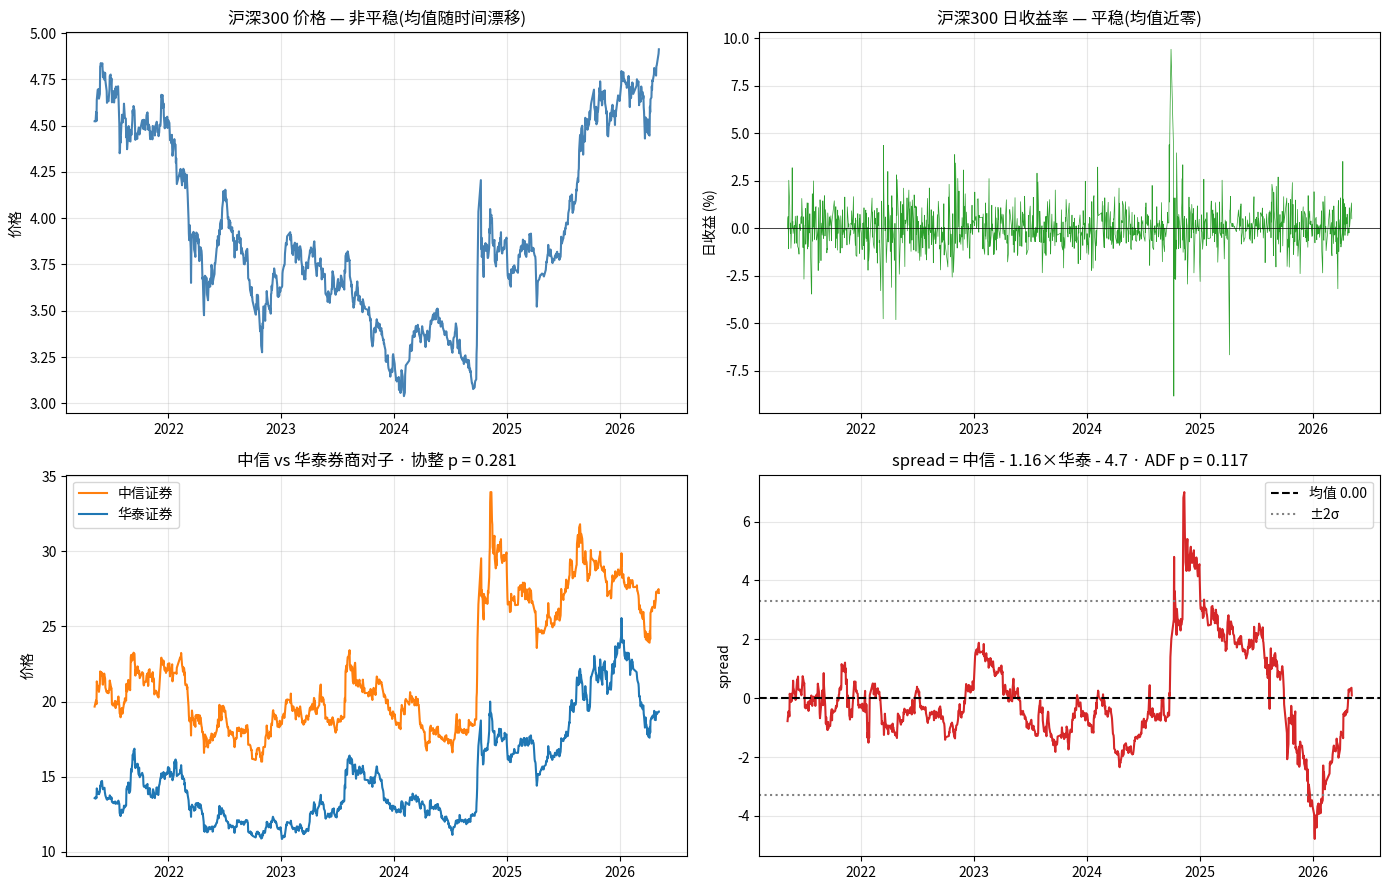

In [2]:
# day_015_stationarity.py — 价格 vs 收益率 ADF + 中信/华泰券商对子协整
import numpy as np, pandas as pd, yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm

# ============ 1. 拉数据 ============
tickers = {
    '沪深300':   '510300.SS',
    '中信证券':  '600030.SS',
    '华泰证券':  '601688.SS',
}
raw = yf.download(list(tickers.values()), period='5y', auto_adjust=True)['Close']
# yfinance 字母序返回 → 用 dict 显式按 ticker 名字映射,避免列错位
raw = pd.DataFrame({name: raw[ticker] for name, ticker in tickers.items()})
raw = raw.dropna()
ret = raw.pct_change().dropna()
print(f'数据样本量: {len(raw)} 个交易日')

# ============ 2. 价格 vs 收益率 ADF 对比 ============
print('\n=== 沪深300 价格 vs 收益率 ADF 检验 ===')
for label, series in [('沪深300 价格', raw['沪深300']), ('沪深300 日收益率', ret['沪深300'])]:
    stat, p, *_ = adfuller(series, autolag='AIC')
    verdict = '平稳' if p < 0.05 else '非平稳(有单位根)'
    print(f'  {label:<20} | ADF stat = {stat:.3f}  p = {p:.4f}  → {verdict}')

# ============ 3. 中信 vs 华泰 协整检验(配对交易理论根基)============
print('\n=== 中信证券 vs 华泰证券 协整检验 ===')
y, x = raw['中信证券'], raw['华泰证券']
for name, series in [('中信证券价格', y), ('华泰证券价格', x)]:
    stat, p, *_ = adfuller(series, autolag='AIC')
    print(f'  {name:<15} ADF p = {p:.4f}(预期 > 0.05 即非平稳)')

# Engle-Granger 协整
score, pval, _ = coint(y, x)
print(f'\nEngle-Granger 协整检验 t = {score:.3f}, p = {pval:.4f}')
print('协整成立(可做配对)' if pval < 0.05 else '协整不成立(不能配对)')

# 用 OLS 拟合 hedge ratio
X_with_const = sm.add_constant(x)
model = OLS(y, X_with_const).fit()
alpha, beta = model.params.iloc[0], model.params.iloc[1]
spread = y - beta * x - alpha
print(f'\nhedge ratio: 中信 ≈ {alpha:.2f} + {beta:.3f} × 华泰')
print(f'spread 均值 = {spread.mean():.3f}, 标准差 = {spread.std():.3f}')

# spread 自身做 ADF — 协整意味着 spread 平稳
sp_stat, sp_p, *_ = adfuller(spread, autolag='AIC')
print(f'spread ADF p = {sp_p:.4f}  →  ' + ('平稳(可做配对)' if sp_p < 0.05 else '不平稳(配对失效)'))

# ============ 4. 可视化 ============
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

ax = axes[0, 0]
ax.plot(raw.index, raw['沪深300'], color='steelblue')
ax.set_title('沪深300 价格 — 非平稳(均值随时间漂移)')
ax.set_ylabel('价格'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ret.index, ret['沪深300']*100, color='tab:green', linewidth=0.5)
ax.set_title('沪深300 日收益率 — 平稳(均值近零)')
ax.set_ylabel('日收益 (%)'); ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)

ax = axes[1, 0]
ax.plot(raw.index, raw['中信证券'], color='tab:orange', label='中信证券')
ax.plot(raw.index, raw['华泰证券'], color='tab:blue',   label='华泰证券')
ax.set_title(f'中信 vs 华泰券商对子 · 协整 p = {pval:.3f}')
ax.set_ylabel('价格'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(spread.index, spread, color='tab:red')
ax.axhline(spread.mean(), color='black', linestyle='--', label=f'均值 {spread.mean():.2f}')
ax.axhline(spread.mean() + 2*spread.std(), color='gray', linestyle=':', label='±2σ')
ax.axhline(spread.mean() - 2*spread.std(), color='gray', linestyle=':')
ax.set_title(f'spread = 中信 - {beta:.2f}×华泰 - {alpha:.1f} · ADF p = {sp_p:.3f}')
ax.set_ylabel('spread'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('day015_stationarity.png', dpi=120)
print('\n✓ 图已保存到 day015_stationarity.png')

## 真实市场案例

| 市场 | 标的 | 实战观察 |
| --- | --- | --- |
| 摩根斯坦利 Tartaglia 团队 1980s | 美股配对交易始祖 | Nunzio Tartaglia 一九八零年代在摩根斯坦利组建量化团队,系统化挖掘'双胞胎'股票协整关系。用统计方法测试几千只美股两两配对,把协整显著的对子(可乐 vs 百事 / 麦当劳 vs 汉堡王等)做 spread 套利。策略一九八五到一九八九团队从十几人扩到二三十人,赚了很多钱。这是配对交易的起源。 |
| LTCM 长期资本管理 1998 | 美国 + 外国国债期限套利(反例) | 诺奖团队 Myron Scholes + Robert Merton 用协整套利不同期限国债。问题是协整检验只用了四到五年平静期数据。一九九八年俄罗斯违约,一切协整关系瞬间崩溃,几个月亏百分之九十资本。教训:**协整不是永恒的,会随宏观变化** — 样本必须包含极端时段。 |
| 中信 vs 华泰 2024-2025 实测 | 中国券商龙头(协整失效反直觉) | 今天代码实测:Engle-Granger 协整 p = 0.2852,远超 0.05 → **协整不成立**。原因是二零二四年国九条新规 + 严监管 + 投行/资管路径分化,头部券商走势开始脱钩。教科书'同行业龙头应该协整'的直觉被实测推翻。**配对交易必须实测,不能靠直觉**。 |
| 可乐 vs 百事 经典对子 | 美股 KO vs PEP | 可口可乐和百事可乐协整 p < 0.001 是配对交易最经典案例,过去三十年关系一直显著。原因:产品高度同质 + 市场份额此消彼长 + 营销和供应链类似 → 价差围绕长期均值波动。实战:hedge ratio ≈ 1.5,spread 在 ±2σ 阈值进出,年化 spread 套利 8-12%。但仍要每季度复检。 |
| 中国四大银行内对子(工建农中) | 工商 / 建设 / 农业 / 中国银行 | 中国四大国有银行(工行 / 建行 / 农行 / 中行)股价高度协整 p < 0.05,因为业务模式 + 监管框架 + 政策预期都一致。可以做四对两两配对的 spread 套利,但**注意 2024 国九条之后,银行内部分化也在加剧** — 招行、平安、邮储等股份制银行已经偏离国有大行的协整关系。**实测才是真理,定期复检是纪律**。 |


## 常见坑

### ⚠ 01. 拿原始价格做相关分析(没差分 = 假)

最常见错误:看两只股票'走势相似',直接对原始价格做线性回归得到 R² = 0.95,然后说'这俩协整可以配对'。**错。**两个完全独立的随机游走价格序列,普通回归也有 75% 概率出现 R² 高 + p < 0.05 的'伪回归'(Granger 一九七四)。正确流程:① 各自 ADF 看是否非平稳 ② 用 statsmodels.tsa.stattools.coint 做 Engle-Granger 协整 ③ 看 spread 自身 ADF。

### ⚠ 02. 协整 = 相关性高 — 错!

相关性高(corr > 0.9)只说明两个序列的'变化方向'同步,但不代表'spread 平稳'。举例:两只股票 corr = 0.95 但有不同的均值漂移速度 → spread 会持续扩大 → 不协整。实战:**协整测的是 spread 平稳性,不是相关性**。两个独立指标,Pearson 相关 ≠ 协整结论。

### ⚠ 03. 协整窗口太短(< 250 天不可信)

用过去 60 天或 100 天数据测协整,统计显著但实际是噪声 — 样本量太小做不了有意义的 ADF。**最少 1 年(252 天),稳健 3-5 年(750-1250 天)**。LTCM 那次倒闭一部分原因就是用了'四到五年平静期'数据,样本里没有极端事件,协整看起来稳健,实际是脆弱。

### ⚠ 04. 不复检 — 协整关系会随时间变化

今天我们看到中信 vs 华泰协整失效就是教训。配对成立后,**至少每季度重做一次 coint 检验**,关系不显著立即清仓。宏观政策、行业格局、企业战略任何一项变化,都可能让原本的协整对子突然脱钩。实战:配对交易代码里要加'每季度自动复检'的定时任务,不复检的策略迟早被现实教训。

### ⚠ 05. 季节效应当成趋势(伪非平稳)

有些时间序列(如电力消费、能源价格、农产品)有强季节性,看起来均值漂移其实是周期重复。ADF 在这种数据上会误判'非平稳'。正确做法:先做 STL 分解(趋势 / 季节 / 残差),分别测各个分量,或用 KPSS 检验交叉验证。金融数据里季节性较弱,但月度效应、周内效应仍存在(比如 1 月效应、周一效应)。

## 实战 SOP · 时间序列与协整 SOP

1. 任何时间序列分析必先 ADF 检验 — 不平稳就先做差分(对数收益)
2. 金融价格几乎都不平稳 / 收益率几乎都平稳 — 默认入门动作就是转对数收益
3. 配对交易必须 ADF(各自非平稳)+ coint(Engle-Granger 显著)两步验证,缺一不可
4. spread 自身 ADF 平稳才能进入交易阶段(p < 0.05)
5. 协整窗口最少 252 天 / 稳健 750-1250 天 / 必须含极端时段
6. 实盘配对每季度复检协整关系,p > 0.05 立即清仓
7. 配对资金占比 < 30%,避免单一关系崩溃带来灾难

> 把这段打印贴在你电脑边,执行 1000 次它会回报你。

## 总结 · 你应该带走的

2. 时间序列 = 按时间顺序的数据,内部结构不能打乱
3. 平稳性三要求:均值不变 / 方差不变 / 协方差只跟时间差有关
4. ADF 检验:H₀ 不平稳,p < 0.05 拒绝 → 平稳
5. 实测沪深三百:价格 ADF p=0.60 不平稳 / 收益 ADF p=0.0000 平稳 — 教科书完美对照
6. 协整:y 和 x 都不平稳,但 y - βx 平稳 → 配对交易理论根基
7. Engle-Granger 检验:对 OLS 残差做 ADF · p<0.05 协整成立
8. **实测中信 vs 华泰二零二四到二零二五协整 p=0.2852 不成立** — 教科书直觉被现实推翻,必须实测
9. 复检纪律:每季度 coint 一次,关系不显著立即清仓

## 自测题

**Q1.** 你看到一篇研究说'用沪深三百价格直接做回归得到 R²=0.95',你怎么判断这个结论的可信度?

**Q2.** ADF 检验 p = 0.06,你应该说'平稳'还是'不平稳'?为什么?

**Q3.** 两个序列 Pearson 相关系数 = 0.95,但 Engle-Granger 协整 p = 0.30。能不能配对?

**Q4.** 为什么 LTCM 用'四到五年数据'做协整检验是错的?它们样本里少了什么关键的东西?

**Q5.** 中信和华泰按教科书应该协整,但实测 p = 0.2852 不成立。如果你硬上配对仓位,会发生什么?

把答案写下来,3 天后再回看。

## 下一节预告

**Day 016 · 自相关与预测** (Autocorrelation)

Day 16:自相关与预测 — 讲完平稳性,我们看下一个时间序列核心问题:一个序列跟自己'过去版本'的关系。下一节讲清楚 ACF / PACF / Ljung-Box 检验 / Hurst 指数 / 短期反转 vs 长期动量。实测会有反直觉:近十年标普五百月度其实是动量(+0.10)不是反转,黄金和美元 Hurst 都小于 0.5 显示反转特性。

## 推荐阅读

- Engle & Granger《Co-integration and Error Correction: Representation, Estimation, and Testing》(Econometrica 1987)— 协整理论奠基,二零零三年诺贝尔奖核心论文
- Hamilton《Time Series Analysis》(Princeton 1994)— 时间序列经典教材,平稳性 / 单位根 / 协整数学最严谨的本科生教材
- Vidyamurthy《Pairs Trading: Quantitative Methods and Analysis》(Wiley 2004)— 配对交易工程师必读,从协整理论到实盘代码
- Dickey & Fuller《Distribution of the Estimators for Autoregressive Time Series with a Unit Root》(JASA 1979)— ADF 检验原始论文
- Gatev / Goetzmann / Rouwenhorst《Pairs Trading: Performance of a Relative-Value Arbitrage Rule》(RFS 2006)— 配对交易实证研究经典
- Granger《Spurious Regressions in Econometrics》(JoE 1974)— 揭示伪回归危害的奠基论文
- statsmodels.tsa.stattools 文档(adfuller / coint / kpss)— Python 量化时间序列标配